# Calculate the spatial gradient of a field on the mesh

TODO:

=> create new solution

=> verify getGradientField method

**Step 1: Create FELiCSMesh, FELiCSSpace and Field**

**Cartesian coordinates:**
Now we calculate the gradient of a scalarField on our mesh. We define our scalar field as follows:
$$\phi(x,y) = \sin(2\pi x)\cos(2\pi y)$$
We have two spatial dimensions (x and y) and we add a spectral dimension in z-direction, which is now our spectral coordinate, to our Field.
With the spectral dimension the scalar field becomes
$$\phi \cdot e^{imz}$$
where m is the wave number. With the wave number we represent a periodicity of the flow in z-direction, while still only calculating a 2D flowfield.

In [1]:
from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh

meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cartesian"
m = 3

# Create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName=coordinateSystemName, meshFileName=meshFileName)

from FELiCS.SpaceDisc.FEMSpaces import getFELiCSSpace

scalarSpace = getFELiCSSpace(mesh, order=2, dim=1)
vectorSpace = getFELiCSSpace(mesh, order=2, dim=3)

from FELiCS.Fields.Field import Field

phi = Field(scalarSpace, mesh=mesh, m = m)
phi.importH5("function_values_sine")
gradPhiSol = Field(vectorSpace, mesh=mesh)
gradPhiSol.importH5("grad_solution_cylSpectral_m=3")

fatal: not a git repository: '/home/frederic/miniforge3/envs/felics2025-env/lib/python3.13/site-packages/../.git'
Info     | FELiCSMesh.py          | __init__                   (line 78  ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 86  ) : Mesh contains 513 nodes and 1024 elements


(         (               (     
)\ )      ) )       (    )\ )  
(()/(  (  (()/( (    )\   (()/(  
/(_)) )\  /(_)))\  (((_)  /(_)) 
(_)_)((_) (_)) ((_) )\___ (_))   
| __|| __|| |   (_)((/ __|/ __|  
| _| | _| | |__ | | | (__ \__ \  
|_|  |___||____||_|  \___||___/  
Git commit: 


**Step 2: Define the gradient Expression and evaluate it on the Field**

We now want to calculate the gradient of our scalar quantity using the `getGradientField()` method of our Field class. This method returns a Field object, which represents a vector-field as we calculate the gradient of a scalar with respect to our two spatial and one spectral dimension. The gradient is defined as
$$\nabla \phi = \left(\frac{\partial \phi}{\partial x}, \frac{\partial \phi}{\partial y}, \frac{\partial \phi}{\partial z}\right)$$
So for our function the analytical gradient is
$$\nabla \phi = \begin{pmatrix}
2\pi \cos(2\pi x) \cos(2\pi y) \cdot e^{imz} \\
-2\pi \sin(2\pi x) \sin(2\pi y) \cdot e^{imz} \\
im \sin(2\pi x) \cos(2\pi y) \cdot e^{imz}
\end{pmatrix}$$
Note that the derivative in the spectral dimension is imaginary. We verify our solution with the analytically obtained gradient.

In [2]:
import numpy as np

gradPhi = phi.getGradientField()

# Calculate analytical solution
def test_function_2(x):
    """Sine wave function: f(x,y) = sin(2*pi*x) * cos(2*pi*y)"""
    return np.sin(2 * np.pi * x[0]) * np.cos(2 * np.pi * x[1])

def dtest_dx(x):
    """Derivative of the sine wave function with respect to x: df/dx = 2*pi*cos(2*pi*x)*cos(2*pi*y)"""
    return 2 * np.pi * np.cos(2 * np.pi * x[0]) * np.cos(2 * np.pi * x[1])

def dtest_dy(x):
    """Derivative of the sine wave function with respect to y: df/dy = -2*pi*sin(2*pi*x)*sin(2*pi*y)"""
    return -2 * np.pi * np.sin(2 * np.pi * x[0]) * np.sin(2 * np.pi * x[1])

# Calculate function values at DOF coordinates
dof_coordinates = vectorSpace.tabulate_dof_coordinates()

function_values_1 = np.zeros(len(dof_coordinates))
function_values_2 = np.zeros(len(dof_coordinates))

for i, coord in enumerate(dof_coordinates):
    function_values_1[i] = dtest_dx(coord)
    function_values_2[i] = dtest_dy(coord)


print(sum(gradPhi.getCoefficientArray() - gradPhiSol.getCoefficientArray()))

(-0.14875251730587813+122.23235562363332j)


**Step 3: Postprocessing**

Visualization of the gradients with matplotlib

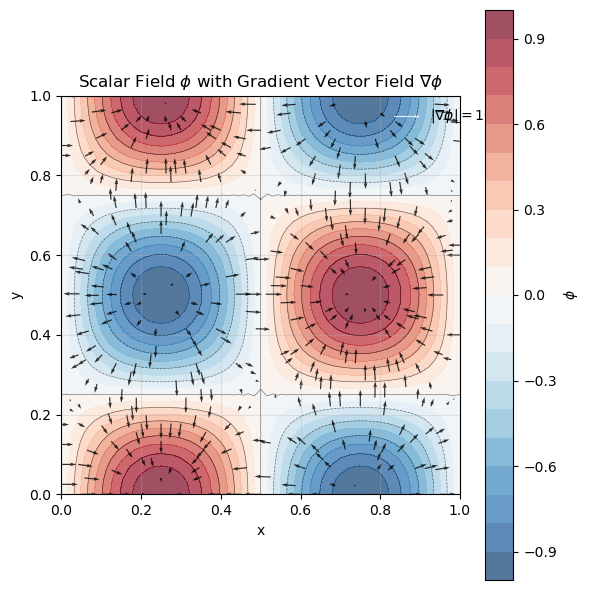

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.tri import Triangulation

# Get DOF coordinates for both scalar and vector spaces
scalar_dof_coords = scalarSpace.tabulate_dof_coordinates()
vector_dof_coords = vectorSpace.tabulate_dof_coordinates()

# Get the field values
phi_values = phi.getCoefficientArray()
gradPhi_x = np.real(gradPhi.getListOfSingleFields()[0].getCoefficientArray())
gradPhi_y = np.real(gradPhi.getListOfSingleFields()[1].getCoefficientArray())


# Extract x and y coordinates
x_scalar = scalar_dof_coords[:, 0]
y_scalar = scalar_dof_coords[:, 1]
x_vector = vector_dof_coords[:, 0]
y_vector = vector_dof_coords[:, 1]

# Extract gradient components (real parts for visualization)
# For vector space with dim=3, we have [grad_x, grad_y, grad_z] components
n_dofs = len(vector_dof_coords)

# Create triangulation for contour plot
triang_scalar = Triangulation(x_scalar, y_scalar)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Create contour plot of phi
contour = ax.tricontourf(triang_scalar, np.real(phi_values), levels=20, cmap='RdBu_r', alpha=0.7)
contour_lines = ax.tricontour(triang_scalar, np.real(phi_values), levels=10, colors='black', alpha=0.5, linewidths=0.5)

# Add colorbar for phi
cbar = plt.colorbar(contour, ax=ax, label=r'$\phi$')

# Add quiver plot of gradient (subsample for clarity)
skip = 5  # Show every 5th vector to avoid overcrowding
quiver = ax.quiver(x_vector[::skip], y_vector[::skip], 
                   gradPhi_x[::skip], gradPhi_y[::skip], 
                   scale=150, alpha=0.8, color='black', width=0.003)

# Add a reference arrow
ax.quiverkey(quiver, 0.9, 0.95, 10, r'$|\nabla\phi| = 10$', 
             labelpos='E', coordinates='axes', color='white')

# Set labels and title
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'Scalar Field $\phi$ with Gradient Vector Field $\nabla\phi$')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()